# Algoritmos que distorsionan lo que crees que piensan los demás

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Una de cada 4 publicaciones que ves de tu propio bando, alabándolo.**

En un feed cronológico simple, era una de cada 7. ¿Cambia eso lo que crees que piensa el resto del país?

---

**Paper:** [Redesigning algorithms to intervene on social norm misperceptions during a national election](https://doi.org/10.1038/s41586-026-10536-1)
*Nature, 2026 · DOI: 10.1038/s41586-026-10536-1*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-27-algoritmos-redes-percepcion-normas/notebook.ipynb)

**Video del canal:** [Ver en YouTube](https://youtube.com/shorts/IQpXQImmOTM)

## Qué hicieron

Un equipo construyó dos feeds desde cero — uno que ordena por engagement — interacción del usuario: likes, comentarios, tiempo de visualización — (como los de las grandes plataformas) y otro cronológico simple — y asignó al azar a 1.818 personas a usar uno u otro durante 8 semanas, antes y después de las elecciones de Estados Unidos en 2024.

La pregunta no era si la gente cambia su comportamiento. Era más sutil: si el algoritmo cambia lo que la gente **cree** que está pasando — qué publica el resto, qué debería publicarse, cuánta animosidad hay entre bandos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_ALGO = '#DC2626'      # feed algorítmico (rojo)
COLOR_CONTROL = '#2563EB'   # feed cronológico (azul)
COLOR_NEUTRO = '#7C3AED'    # destacado
FUENTE = 'Fuente: Brady et al. (2026), Nature | Datos: Study 4 (n=1818, 8 semanas, US 2024)'

# Setup
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar los CSVs verificados
expo_bando = pd.read_csv('datos/exposicion_propio_bando.csv')
expo_categoria = pd.read_csv('datos/exposicion_categoria.csv')
outcomes = pd.read_csv('datos/outcomes_resumen.csv')
survey = pd.read_csv('datos/survey_por_participante.csv')
engagement = pd.read_csv('datos/engagement_feed2.csv')
demograf = pd.read_csv('datos/demograficos_por_condicion.csv')

print(f'Participantes (post-exclusión): {len(survey):,}')
print(f'  Algorítmico: {(survey.condition == "algorithmic").sum():,}')
print(f'  Cronológico: {(survey.condition == "control").sum():,}')
print(f'Outcomes evaluados: {len(outcomes)}')

Participantes (post-exclusión): 1,818
  Algorítmico: 906
  Cronológico: 912
Outcomes evaluados: 10


Aquí está la primera diferencia.

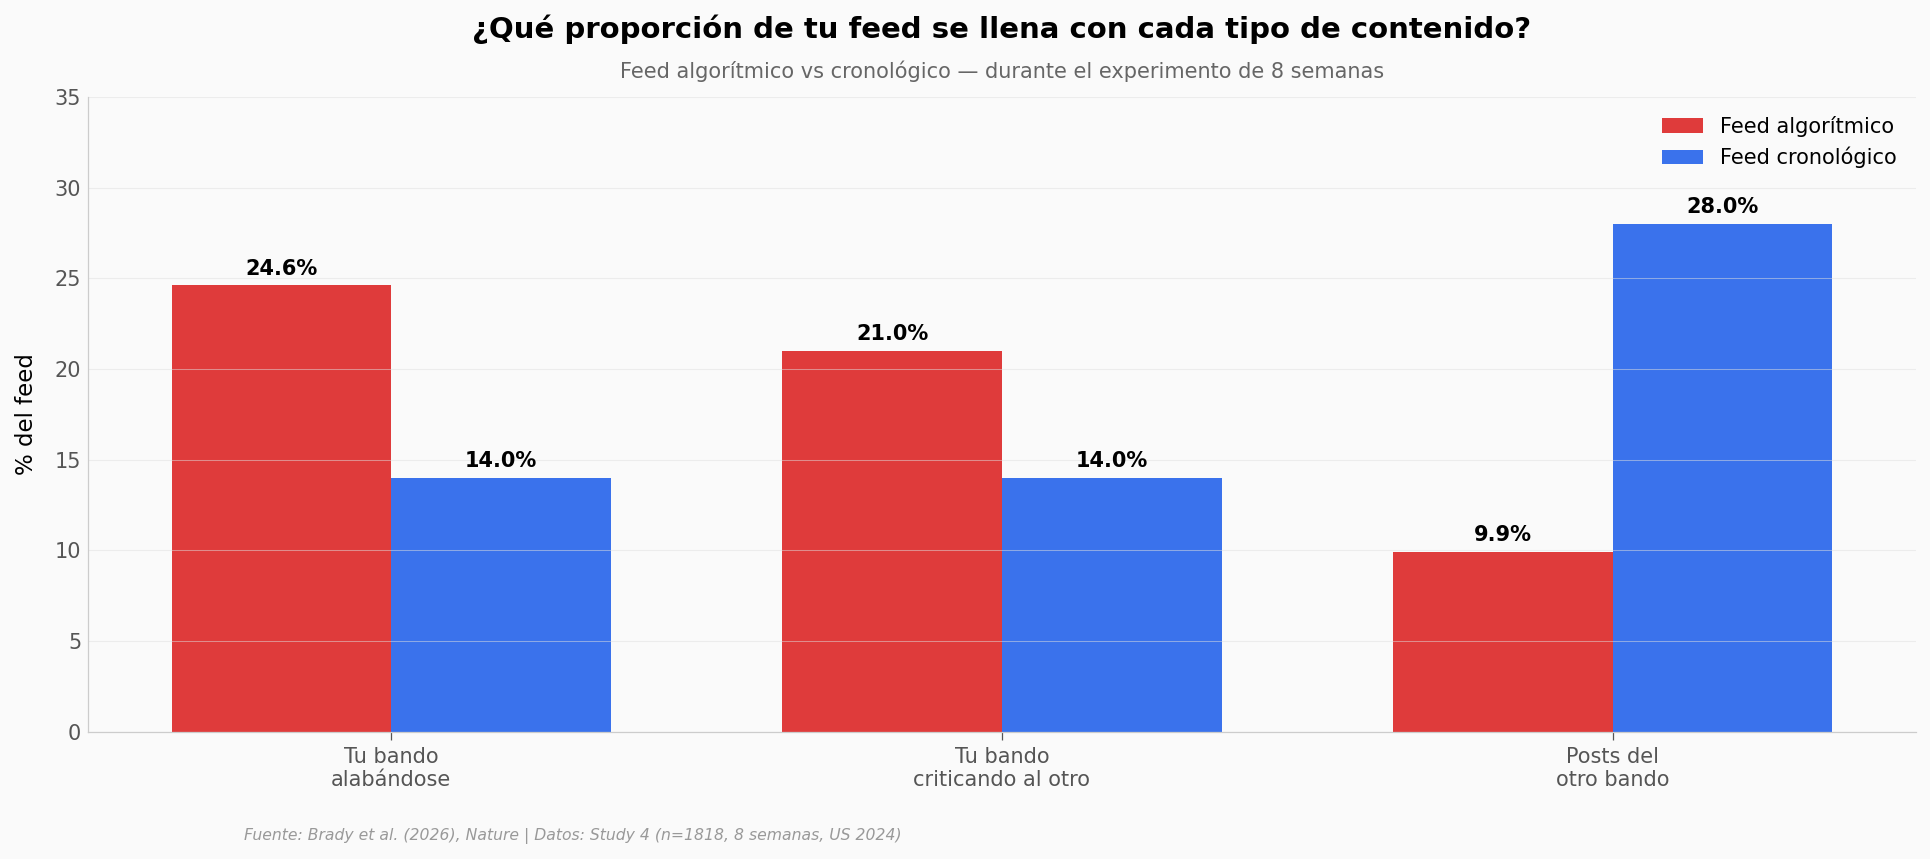

In [2]:
# Tomamos las 3 categorías clave de exposición
# (qué proporción del feed era de cada tipo)
pivot = expo_bando.pivot(index='own_view', columns='condition', values='pct')

# Reordenar para que la historia se cuente bien
orden = ['ingroup_praise', 'outgroup_blame', 'other_party']
etiquetas = ['Tu bando\nalabándose', 'Tu bando\ncriticando al otro', 'Posts del\notro bando']

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(orden))
ancho = 0.36

barras_algo = ax.bar(x - ancho/2, [pivot.loc[c, 'algorithmic'] for c in orden],
                     ancho, color=COLOR_ALGO, label='Feed algorítmico', alpha=0.9)
barras_ctrl = ax.bar(x + ancho/2, [pivot.loc[c, 'control'] for c in orden],
                     ancho, color=COLOR_CONTROL, label='Feed cronológico', alpha=0.9)

# Valores arriba de cada barra
for barras in [barras_algo, barras_ctrl]:
    for b in barras:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.6,
                f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylabel('% del feed', fontsize=11)
ax.set_title('¿Qué proporción de tu feed se llena con cada tipo de contenido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Feed algorítmico vs cronológico — durante el experimento de 8 semanas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 35)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_exposicion_por_bando.png', dpi=200, bbox_inches='tight')
plt.show()

El algoritmo no es neutral con lo que te muestra.

Cuando ordena por engagement, casi duplica las publicaciones del propio bando alabándose — del 14% al 24,6% del feed. Las del propio bando criticando al otro bando suben 7 puntos. Y las del **otro** bando caen a la tercera parte: del 28% al 9,9%.

Visto desde adentro del feed: con el algoritmo, más de 8 de cada 10 publicaciones partidistas que ves son del bando con el que ya estás alineado.

## Lo que ves cambia lo que crees

Ese es el primer dato. El más interesante es el segundo: si tu feed muestra más contenido tribal, ¿empiezas a creer que el resto de la gente piensa así?

El equipo midió 10 outcomes en encuestas — algunos *descriptivos* (qué cree el participante que la gente hace) y otros *prescriptivos* (qué cree que la gente debería hacer).

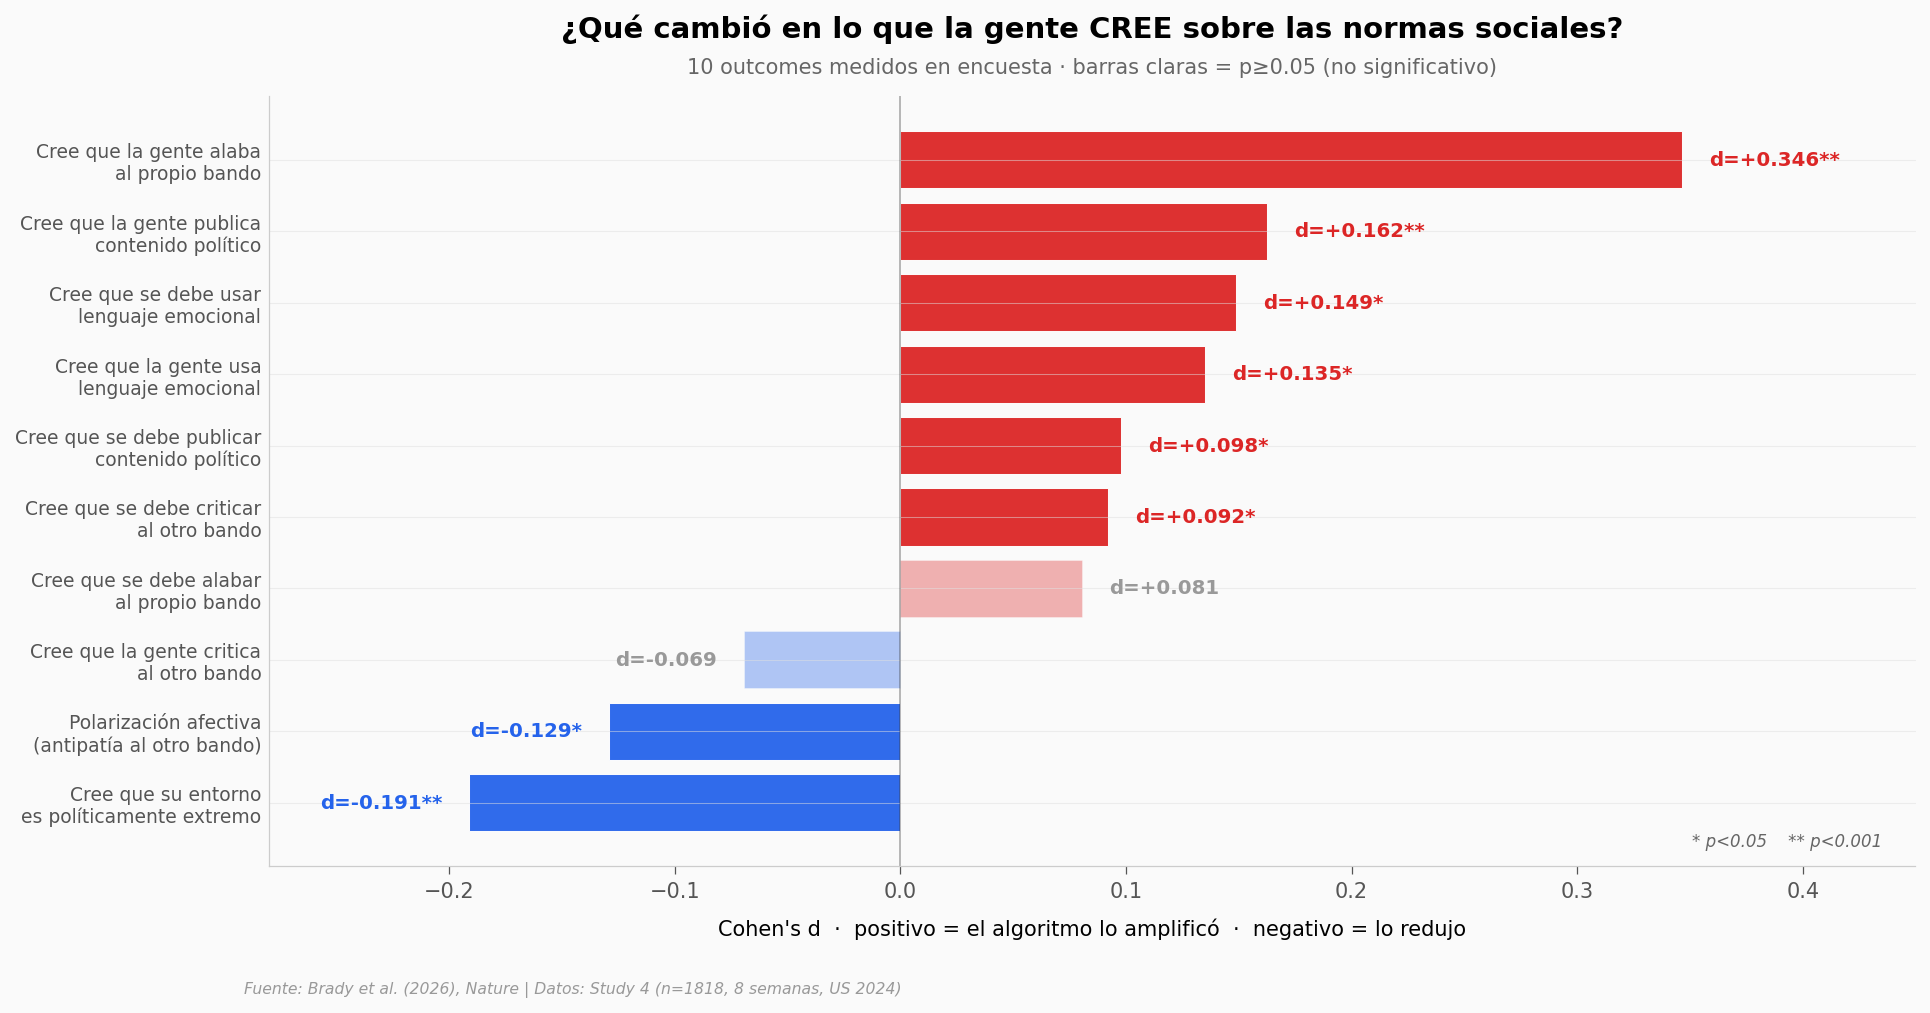

In [3]:
# Ordenar outcomes por magnitud del efecto (Cohen's d absoluto)
outc = outcomes.copy()
outc = outc.sort_values('cohens_d', ascending=True).reset_index(drop=True)

# Etiquetas legibles
mapa = {
    'praise_descriptive': 'Cree que la gente alaba\nal propio bando',
    'political_descriptive': 'Cree que la gente publica\ncontenido político',
    'emotion_prescriptive': 'Cree que se debe usar\nlenguaje emocional',
    'emotion_descriptive': 'Cree que la gente usa\nlenguaje emocional',
    'poli_prescriptive': 'Cree que se debe publicar\ncontenido político',
    'blame_prescriptive': 'Cree que se debe criticar\nal otro bando',
    'blame_descriptive': 'Cree que la gente critica\nal otro bando',
    'praise_prescriptive': 'Cree que se debe alabar\nal propio bando',
    'affect_polarization': 'Polarización afectiva\n(antipatía al otro bando)',
    'poli_extreme': 'Cree que su entorno\nes políticamente extremo',
}
outc['label'] = outc['outcome'].map(mapa)

# Color: rojo = el algoritmo lo SUBIÓ, azul = lo BAJÓ (efecto inverso)
outc['color'] = outc['cohens_d'].apply(lambda d: COLOR_ALGO if d > 0 else COLOR_CONTROL)
outc['alpha'] = outc['p_value'].apply(lambda p: 0.95 if p < 0.05 else 0.35)

fig, ax = plt.subplots(figsize=(13, 6.5))
ypos = np.arange(len(outc))

for i, row in outc.iterrows():
    ax.barh(i, row['cohens_d'], color=row['color'], alpha=row['alpha'],
            edgecolor='white', linewidth=0.5)
    # Valor de d a la derecha (o izquierda si negativo)
    offset = 0.012 if row['cohens_d'] >= 0 else -0.012
    ha = 'left' if row['cohens_d'] >= 0 else 'right'
    sig = '' if row['p_value'] >= 0.05 else ('*' if row['p_value'] >= 0.001 else '**')
    ax.text(row['cohens_d'] + offset, i,
            f"d={row['cohens_d']:+.3f}{sig}",
            ha=ha, va='center', fontsize=9.5, fontweight='bold',
            color=row['color'] if row['p_value'] < 0.05 else '#999999')

ax.axvline(0, color='#333333', linewidth=0.8, alpha=0.4)
ax.set_yticks(ypos)
ax.set_yticklabels(outc['label'], fontsize=9)
ax.set_xlabel("Cohen's d  ·  positivo = el algoritmo lo amplificó  ·  negativo = lo redujo", fontsize=10)
ax.set_title('¿Qué cambió en lo que la gente CREE sobre las normas sociales?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '10 outcomes medidos en encuesta · barras claras = p≥0.05 (no significativo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.28, 0.45)

# Nota de significancia
ax.text(0.98, 0.02, '* p<0.05    ** p<0.001', transform=ax.transAxes,
        fontsize=8, color='#666666', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_effect_sizes_outcomes.png', dpi=200, bbox_inches='tight')
plt.show()

El efecto más limpio aparece arriba del gráfico: la creencia de que la gente alaba al propio bando. Con un d de 0,346 — un efecto medio en términos de la convención de Cohen — y un p casi imposible de explicar por azar (1,1 × 10⁻¹³).

Eso suena abstracto. Veamos cómo se distribuye en las dos condiciones.

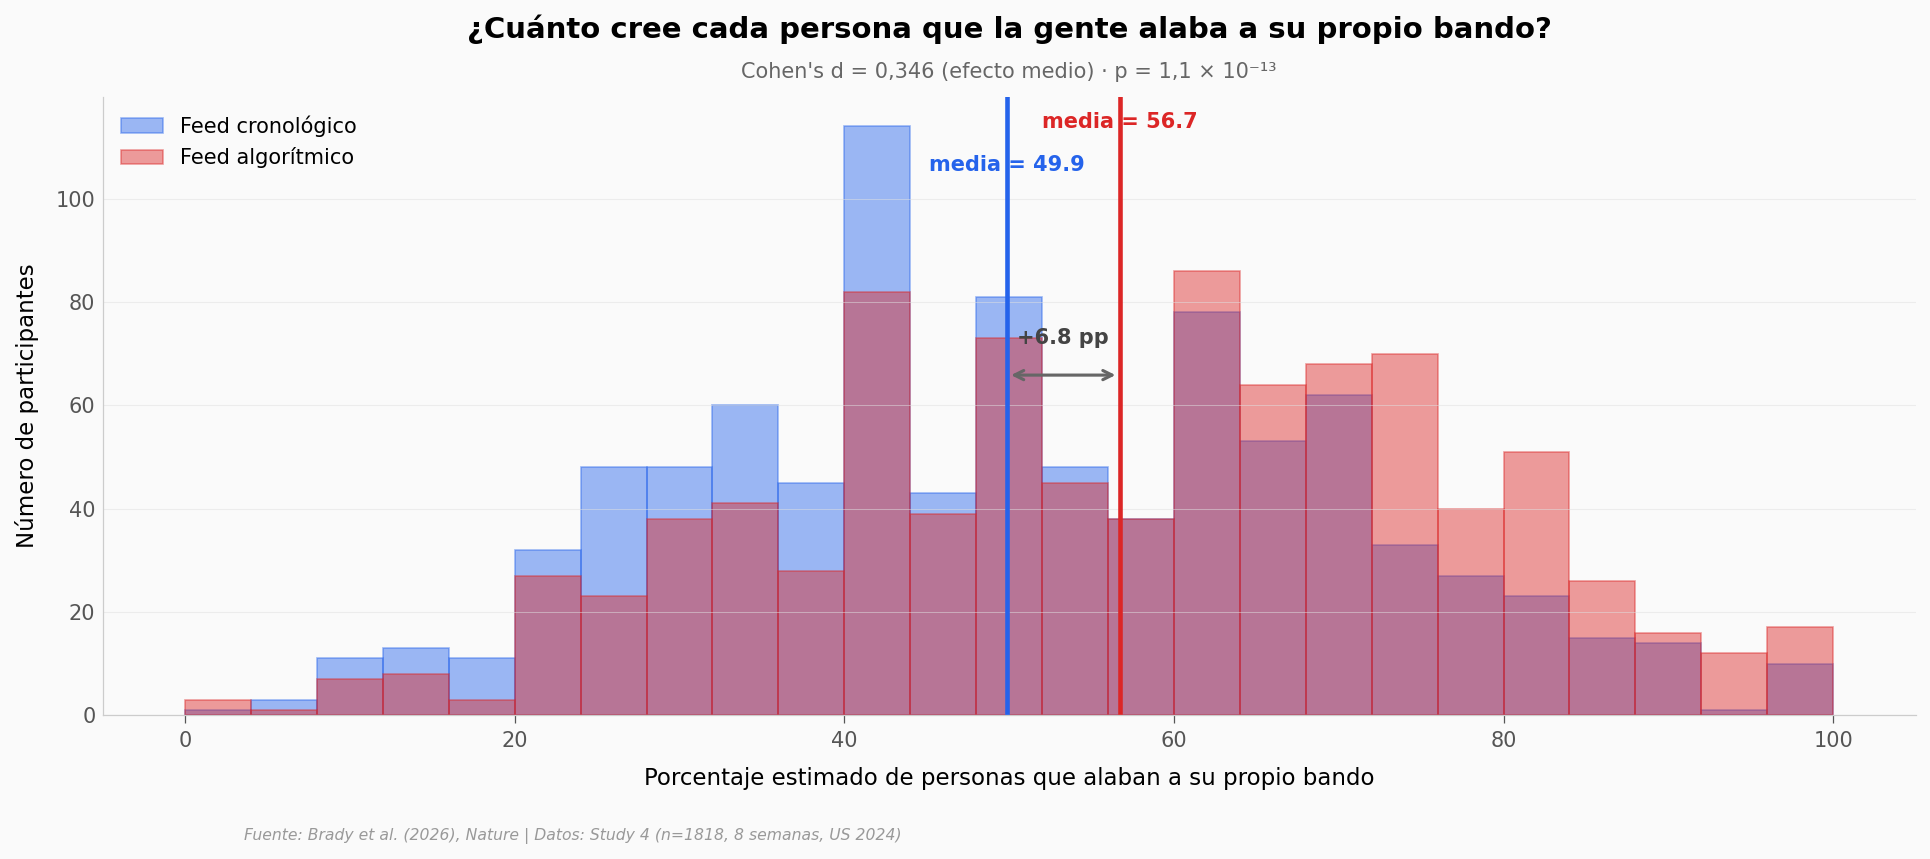

Welch t-test: t = 7.384, p = 2.32e-13
Cohen's d (pooled SD): 0.346


In [4]:
# Distribución del outcome con mayor efecto
algo_vals = survey[survey.condition == 'algorithmic']['praise_descriptive'].dropna()
ctrl_vals = survey[survey.condition == 'control']['praise_descriptive'].dropna()

fig, ax = plt.subplots(figsize=(13, 5.5))
bins = np.linspace(0, 100, 26)
ax.hist(ctrl_vals, bins=bins, color=COLOR_CONTROL, alpha=0.45,
        edgecolor=COLOR_CONTROL, linewidth=0.8, label='Feed cronológico')
ax.hist(algo_vals, bins=bins, color=COLOR_ALGO, alpha=0.45,
        edgecolor=COLOR_ALGO, linewidth=0.8, label='Feed algorítmico')

# Medias verticales
m_algo = algo_vals.mean()
m_ctrl = ctrl_vals.mean()
ax.axvline(m_algo, color=COLOR_ALGO, linewidth=2.2, linestyle='-')
ax.axvline(m_ctrl, color=COLOR_CONTROL, linewidth=2.2, linestyle='-')

# Anotaciones de medias
y_top = ax.get_ylim()[1]
ax.text(m_algo, y_top * 0.95, f'media = {m_algo:.1f}',
        color=COLOR_ALGO, fontsize=10, fontweight='bold', ha='center')
ax.text(m_ctrl, y_top * 0.88, f'media = {m_ctrl:.1f}',
        color=COLOR_CONTROL, fontsize=10, fontweight='bold', ha='center')

# Flecha de diferencia
ax.annotate('', xy=(m_algo, y_top * 0.55), xytext=(m_ctrl, y_top * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((m_algo + m_ctrl) / 2, y_top * 0.60,
        f'+{m_algo - m_ctrl:.1f} pp', ha='center', fontsize=10,
        color='#444444', fontweight='bold')

ax.set_xlabel('Porcentaje estimado de personas que alaban a su propio bando', fontsize=11)
ax.set_ylabel('Número de participantes', fontsize=11)
ax.set_title('¿Cuánto cree cada persona que la gente alaba a su propio bando?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, "Cohen's d = 0,346 (efecto medio) · p = 1,1 × 10⁻¹³",
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_praise_descriptive_dist.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificación rápida
t, p = stats.ttest_ind(algo_vals, ctrl_vals, equal_var=False)
n1, n2 = len(algo_vals), len(ctrl_vals)
s1, s2 = algo_vals.std(ddof=1), ctrl_vals.std(ddof=1)
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
d = (m_algo - m_ctrl) / sp
print(f"Welch t-test: t = {t:.3f}, p = {p:.2e}")
print(f"Cohen's d (pooled SD): {d:.3f}")

## Pero hay dos sorpresas

El abstract del paper anticipa que los efectos van en **dirección inesperada** en algunos outcomes. Cuando uno los mira con calma, son dos.

Volvamos al forest plot de antes y miremos solo las dos barras azules — los outcomes donde el feed algorítmico, en vez de empujar en la dirección que se esperaba, **empujó al contrario**.

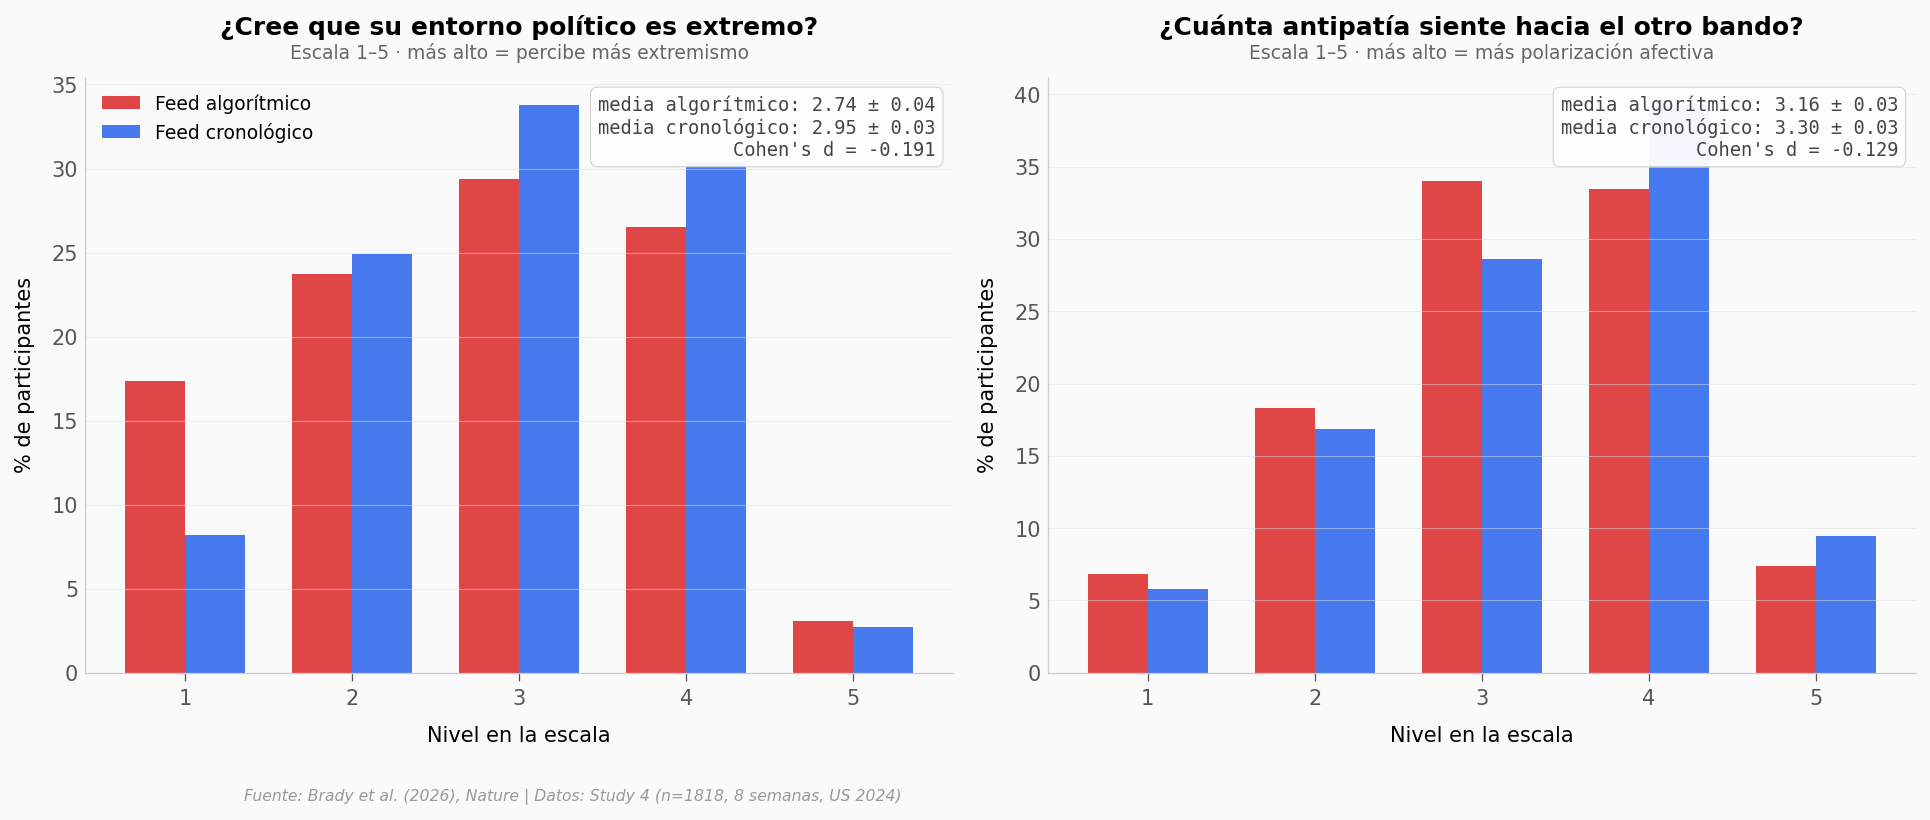

In [5]:
# Los dos efectos invertidos: poli_extreme y affect_polarization
# Distribución por categoría Likert (1-7) en cada condición
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, outcome, titulo, subtitulo in [
    (axes[0], 'poli_extreme',
     '¿Cree que su entorno político es extremo?',
     'Escala 1–5 · más alto = percibe más extremismo'),
    (axes[1], 'affect_polarization',
     '¿Cuánta antipatía siente hacia el otro bando?',
     'Escala 1–5 · más alto = más polarización afectiva'),
]:
    algo = survey[survey.condition == 'algorithmic'][outcome].dropna()
    ctrl = survey[survey.condition == 'control'][outcome].dropna()
    m_a, m_c = algo.mean(), ctrl.mean()
    sem_a = algo.std(ddof=1) / np.sqrt(len(algo))
    sem_c = ctrl.std(ddof=1) / np.sqrt(len(ctrl))
    d = (m_a - m_c) / np.sqrt(((len(algo)-1)*algo.var(ddof=1) +
                               (len(ctrl)-1)*ctrl.var(ddof=1)) /
                              (len(algo)+len(ctrl)-2))

    # Distribución como porcentaje en cada nivel Likert
    niveles = sorted(set(algo.unique()) | set(ctrl.unique()))
    pct_algo = [100.0 * (algo == n).sum() / len(algo) for n in niveles]
    pct_ctrl = [100.0 * (ctrl == n).sum() / len(ctrl) for n in niveles]

    x = np.arange(len(niveles))
    ancho = 0.36
    ax.bar(x - ancho/2, pct_algo, ancho, color=COLOR_ALGO, alpha=0.85,
           label='Feed algorítmico')
    ax.bar(x + ancho/2, pct_ctrl, ancho, color=COLOR_CONTROL, alpha=0.85,
           label='Feed cronológico')

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(n)) for n in niveles], fontsize=10)
    ax.set_xlabel('Nivel en la escala', fontsize=10)
    ax.set_ylabel('% de participantes', fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=20)
    ax.text(0.5, 1.03, subtitulo, transform=ax.transAxes,
            fontsize=9, color='#666666', ha='center')
    # Recuadro con estadísticas
    ax.text(0.98, 0.97,
            f'media algorítmico: {m_a:.2f} ± {sem_a:.2f}\n'
            f'media cronológico: {m_c:.2f} ± {sem_c:.2f}\n'
            f"Cohen's d = {d:+.3f}",
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            color='#444444', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cccccc', alpha=0.95))
    if ax is axes[0]:
        ax.legend(loc='upper left', fontsize=9, framealpha=0.95)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_efectos_invertidos.png', dpi=200, bbox_inches='tight')
plt.show()

Dos resultados van al revés de lo esperado:

- La gente con feed algorítmico ve **menos** extremismo a su alrededor (d = −0,19).
- Y siente **menos** antipatía hacia el otro bando que la gente del feed cronológico (d = −0,13).

Ambos son efectos pequeños pero significativos. Y suenan contraintuitivos: si el algoritmo amplifica contenido del propio bando alabándose y critica al otro, ¿no debería **subir** la polarización?

Una lectura cautelosa: el algoritmo está mostrando menos contenido del otro bando — y menos contenido es menos oportunidad de reaccionar a él. Los participantes saben que están en un experimento; los autores aclaran que estos efectos podrían no replicar en uso "natural" donde el feed cronológico no es la norma. Es un dato real del estudio, pero no es la historia principal.

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El feed algorítmico casi duplica la exposición al propio bando alabándose (14% → 24,6%) | ✅ | Datos directos de `exposicion_propio_bando.csv` (n = 136.898 trials de exposición). |
| El feed algorítmico reduce a un tercio la exposición al otro bando (28% → 9,9%) | ✅ | Mismo dataset. |
| Los usuarios del feed algorítmico creen que se alaba más al propio bando (+6,8 pp) | ✅ | d = 0,346, p = 1,1 × 10⁻¹³ — el efecto más limpio del estudio. |
| Los usuarios creen que se debe usar más lenguaje emocional | ✅ | d = 0,15, p = 0,0014 — efecto pequeño-medio significativo. |
| El algoritmo redujo la polarización afectiva | ⚠️ | d = −0,13, p = 0,003. Real en este experimento, pero el paper lo enmarca como dirección inesperada — no extrapolar fuera del diseño. |
| El comportamiento propio (likes, shares) no cambió | ⚠️ | Likes subieron de 19,2% a 27,4% y shares de 9,5% a 12,1% en el experimento. El paper se refiere a *engagement controlado por contenido idéntico*; al ver más contenido del propio bando, naturalmente se interactúa más con él. |

> **Limitaciones:**
> - Solo Estados Unidos, una elección, 8 semanas — no es claro qué pasaría en otros contextos políticos.
> - Los participantes sabían que estaban en un experimento. El efecto Hawthorne puede atenuar algunos cambios.
> - El feed cronológico no es la línea base real de las plataformas — es una línea base *teórica*. Los efectos están medidos contra ese contraste, no contra el feed habitual del usuario.
> - La tercera condición del paper (algoritmo "diversified extremity") no está en este CSV abierto.

## Ahora tú

1. **¿Cambia el efecto según afiliación política?** El dataset tiene `political_affiliation`. Mira si los republicanos y demócratas mostraron la misma magnitud de cambio en `praise_descriptive`.
   - *Pista:* `survey.groupby(['political_affiliation', 'condition'])['praise_descriptive'].mean()`

2. **¿Qué outcome correlaciona más con `affect_polarization`?** Si la polarización afectiva bajó con el algoritmo, ¿se mueve junto con algún outcome de percepción?
   - *Pista:* `survey[outcomes_list].corr()['affect_polarization']`

3. **¿Hay un sub-grupo que reacciona al revés?** En el outcome más fuerte (`praise_descriptive`), ¿hay personas en `algorithmic` que terminaron con valores **más bajos** que la media del grupo `control`?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿El efecto es del mismo tamaño para demócratas y republicanos?

# Recodificar lean -> bando principal
mapa_partido = {'democrat': 'demócrata', 'lean_democrat': 'demócrata',
                'republican': 'republicano', 'lean_republican': 'republicano'}
df = survey.copy()
df['partido'] = df['political_affiliation'].map(mapa_partido)
df = df.dropna(subset=['partido', 'praise_descriptive'])

resumen = df.groupby(['partido', 'condition'])['praise_descriptive'].agg(
    ['mean', 'std', 'count']).round(2)
print('praise_descriptive por afiliación × condición:')
print(resumen)
print()

# Cohen's d por partido
for partido in ['demócrata', 'republicano']:
    sub = df[df.partido == partido]
    algo = sub[sub.condition == 'algorithmic']['praise_descriptive']
    ctrl = sub[sub.condition == 'control']['praise_descriptive']
    pooled_sd = np.sqrt(((len(algo)-1)*algo.var(ddof=1) +
                         (len(ctrl)-1)*ctrl.var(ddof=1)) / (len(algo)+len(ctrl)-2))
    d = (algo.mean() - ctrl.mean()) / pooled_sd
    t, p = stats.ttest_ind(algo, ctrl, equal_var=False)
    print(f'{partido:>12}: d = {d:.3f}  ·  diff = {algo.mean() - ctrl.mean():+.2f} pp  ·  p = {p:.2e}  ·  n = {len(sub)}')

praise_descriptive por afiliación × condición:
                          mean    std  count
partido     condition                       
demócrata   algorithmic  56.66  19.61    543
            control      48.13  18.72    545
republicano algorithmic  56.79  20.81    363
            control      52.44  20.16    367

   demócrata: d = 0.445  ·  diff = +8.53 pp  ·  p = 4.30e-13  ·  n = 1088
 republicano: d = 0.212  ·  diff = +4.34 pp  ·  p = 4.31e-03  ·  n = 730


## Fuentes

**Paper**: [Redesigning algorithms to intervene on social norm misperceptions during a national election](https://doi.org/10.1038/s41586-026-10536-1)  
*Nature, 2026-05-27*

**Dataset canónico**: [Attention Algorithm Amplification — Study 4 combined data and analysis script](https://osf.io/wy67k/)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad:** los CSVs en `datos/` se derivan del archivo `study4_combined_data.csv` (Supplementary Materials del paper en Nature). Filtros aplicados: 83 participantes excluidos por feed_duration < 100 s o > 5 NA en post_dwell_seconds — mismo criterio que el script R original de los autores.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia datos: ver paper. · Licencia código: MIT.